In [111]:
%load_ext autoreload
%autoreload 2

import torch
import torch.nn as nn
import numpy as np

from torch.utils.data import TensorDataset, DataLoader
from torch.nn.utils import parameters_to_vector, vector_to_parameters
from tqdm import tqdm
from collections import defaultdict
import matplotlib.pyplot as plt

from sv3.nn import FunctionalModelJac, MLP
from sv3.svd_sgd import SVDOptimizer

import sys
sys.path.append('..')
import copy

from experiments.experiment_code.experiment_utils import train_loop_standard, train_loop_svd

device = torch.device('cuda' if torch.cuda.is_available() else ('mps' if torch.backends.mps.is_available() else 'cpu'))
print(f"Using device: {device}")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Using device: mps


In [112]:
from torchvision import datasets, transforms
from experiments.datasets import Toy1DRegressionDataset

toy_1d = Toy1DRegressionDataset()
train_dataset = toy_1d.train_dataset
test_dataset = toy_1d.val_dataset

In [117]:
mlp_width = 128
n_layer = 3
mlp_kwargs = {
    'input_dim': 1,
    'hidden_dims': [mlp_width]*n_layer,
    'output_dim': 1
}
mlp_base = MLP(**mlp_kwargs)
init_state = copy.deepcopy(mlp_base.state_dict())
print(f"MLP has {sum(p.numel() for p in mlp_base.parameters())} parameters.")
del mlp_base # free memory

MLP has 33409 parameters.


In [118]:
LOADER_SEED = 645297
batch_size = 64
n_epoch = 5
K = 32
RTOL = 1e-3
LR = 0.1

In [119]:
model_adam = MLP(**mlp_kwargs)
model_adam.load_state_dict(init_state)
model_adam = model_adam.to(device)

optimizer = torch.optim.Adam(model_adam.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()

train_loader = DataLoader(toy_1d.train_dataset, batch_size=batch_size, shuffle=True, generator=torch.Generator().manual_seed(LOADER_SEED))
test_loader = DataLoader(toy_1d.val_dataset, batch_size=256, shuffle=False)

model_adam, losses_adam = train_loop_standard(model_adam, optimizer, loss_fn, train_loader, test_loader, n_epoch, device, track_acc=True)

Using device cpu


100%|██████████| 5/5 [00:00<00:00,  5.75it/s]


In [120]:
device = 'cpu'
model_svd = MLP(**mlp_kwargs)
model_svd.load_state_dict(init_state)
model_svd = model_svd.to(device)

def loss_fn(pred,y):
    loss = (pred - y)**2
    loss = loss.sum(dim=-1)
    return loss

model_svd = FunctionalModelJac(model_svd, loss_fn, device=device, param_fraction=None, mask_by_block=False)
optimizer = SVDOptimizer(model_svd,lr=LR,k=K,rtol=RTOL,track_svd_info=True,svd_mode='randomized')


train_loader = DataLoader(toy_1d.train_dataset, batch_size=batch_size, shuffle=True, generator=torch.Generator().manual_seed(LOADER_SEED),drop_last=True)
test_loader = DataLoader(toy_1d.val_dataset, batch_size=256, shuffle=False)

model_svd, losses_run, optimizer = train_loop_svd(model_svd,optimizer,loss_fn,train_loader,test_loader,n_epoch,device,track_acc=True)
svd_info = optimizer.svd_info
losses_svd = losses_run

torch.compiler.reset()

  0%|          | 0/5 [00:00<?, ?it/s]/Users/sambt/miniforge3/envs/jax/lib/python3.12/site-packages/torch/_inductor/lowering.py:1725: FutureWarning: `torch._prims_common.check` is deprecated and will be removed in the future. Please use `torch._check*` functions instead.
  check(
100%|██████████| 5/5 [00:49<00:00, 10.00s/it]


### Compare

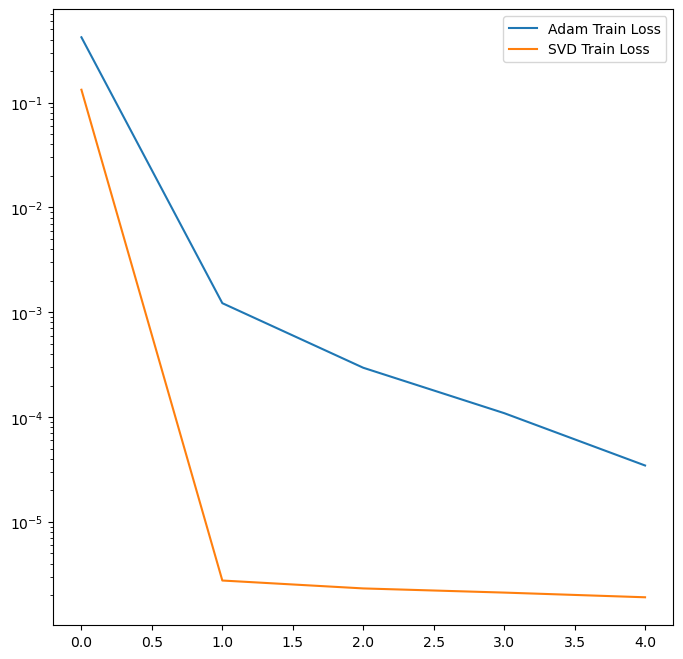

In [121]:
fig, ax = plt.subplots(figsize=(8,8))
ax.plot(np.arange(len(losses_adam['train'])), losses_adam['train'], label='Adam Train Loss')
ax.plot(np.arange(len(losses_svd['train'])), losses_svd['train'], label=f'SVD Train Loss')
plt.yscale('log')
plt.legend()

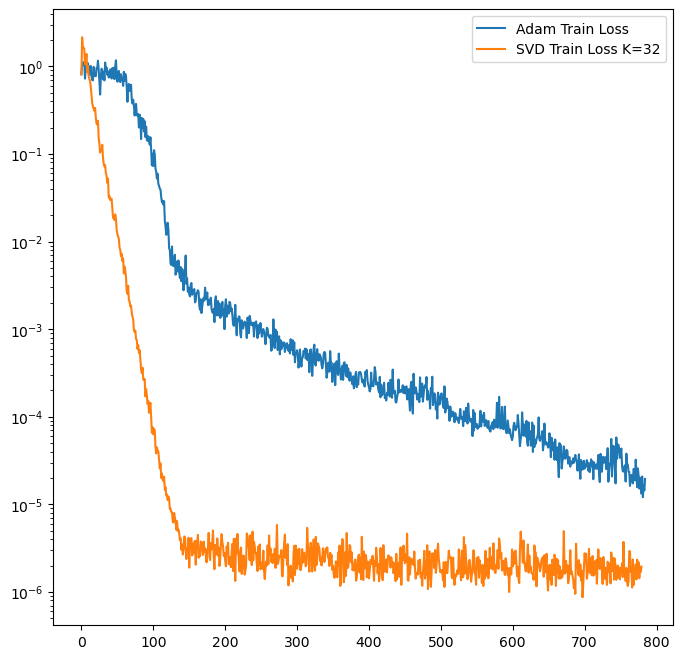

In [122]:
fig, ax = plt.subplots(figsize=(8,8))
ax.plot(np.arange(len(losses_adam['train_batch'])), losses_adam['train_batch'], label='Adam Train Loss')
ax.plot(np.arange(len(losses_svd['train_batch'])), losses_svd['train_batch'], label=f'SVD Train Loss K={K}')
plt.yscale('log')
plt.legend()

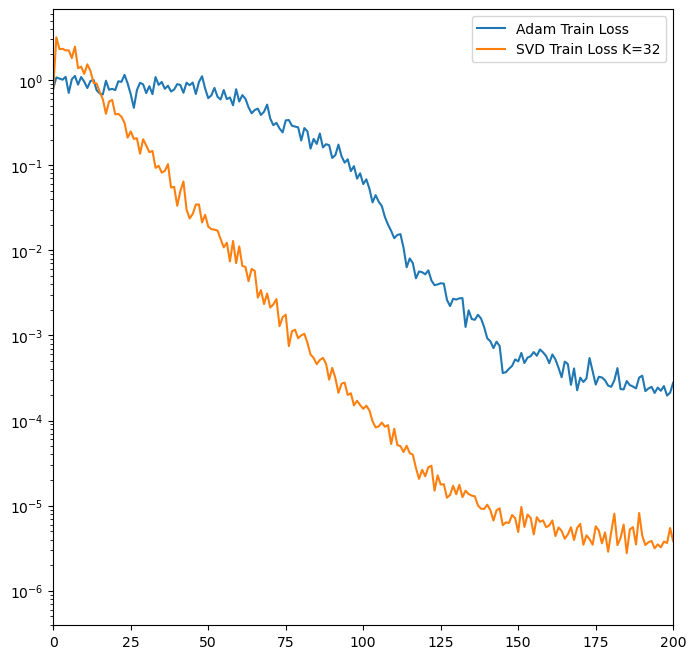

In [95]:
fig, ax = plt.subplots(figsize=(8,8))
ax.plot(np.arange(len(losses_adam['train_batch'])), losses_adam['train_batch'], label='Adam Train Loss')
ax.plot(np.arange(len(losses_svd['train_batch'])), losses_svd['train_batch'], label=f'SVD Train Loss K={K}')
plt.yscale('log')
ax.set_xlim(0,200)
plt.legend()

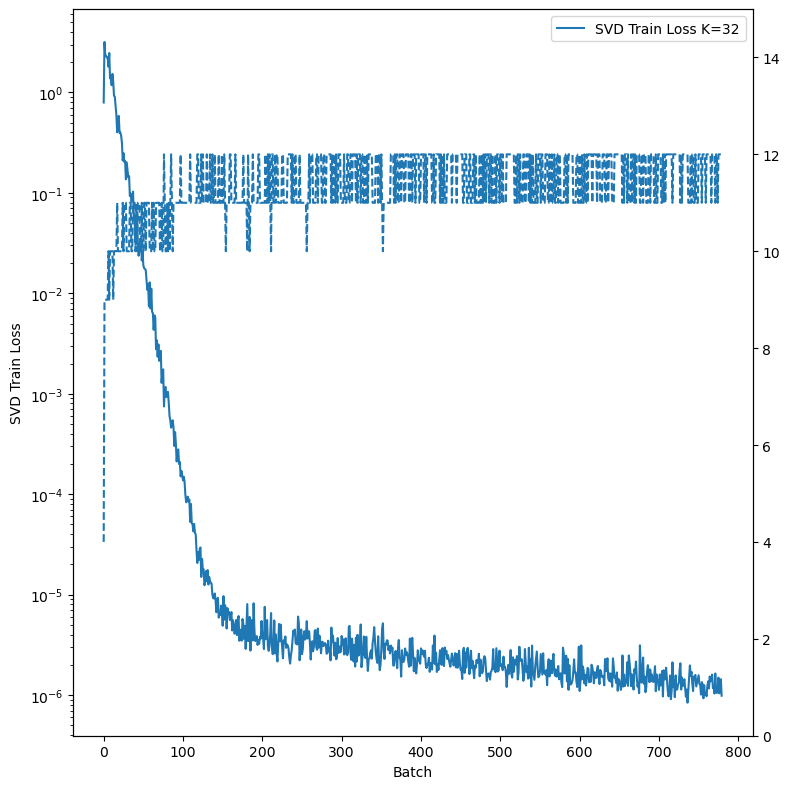

In [96]:
fig, ax1 = plt.subplots(figsize=(8,8))

plots = []
p1 = ax1.plot(np.arange(len(losses_svd['train_batch'])), losses_svd['train_batch'], f'C0-', label=f'SVD Train Loss K={K}')
plots.append(p1[0])
ax1.set_xlabel('Batch')
ax1.set_ylabel('SVD Train Loss')
ax1.set_yscale('log')
ax1.legend()

ax2 = ax1.twinx()
p2 = ax2.plot(np.arange(len(svd_info['num_nonzero_svs'])), svd_info['num_nonzero_svs'], f'C0--',label=f'Number of Nonzero SVs K={K}')
ax2.set_ylim(0,15)

ax1.legend(handles=plots,ncol=2)
plt.tight_layout()